In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"Libraries imported successfully")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Libraries imported successfully
Device: cuda
GPU: NVIDIA GeForce RTX 5090


In [2]:
ratings = pd.read_csv('../data/ml-25m/ratings.csv')
movies = pd.read_csv('../data/ml-25m/movies.csv')
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

split_date = '2015-01-01'
train = ratings[ratings['datetime'] < split_date].copy()
test = ratings[ratings['datetime'] >= split_date].copy()

min_rating = 0.5
max_rating = 5.0
train['rating'] = (train['rating'] - min_rating) / (max_rating - min_rating)
test['rating'] = (test['rating'] - min_rating) / (max_rating - min_rating)

print(f"Train: {len(train):,} ratings")
print(f"Test:  {len(test):,} ratings")
print(f"Movies: {len(movies):,}")
print(f"Rating range: {train['rating'].min():.2f} - {train['rating'].max():.2f}")

Train: 17,436,354 ratings
Test:  7,563,741 ratings
Movies: 62,423
Rating range: 0.00 - 1.00


In [3]:
user_ids = train['userId'].unique()
movie_ids = train['movieId'].unique()

user_id_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

index_to_user_id = {idx: user_id for user_id, idx in user_id_to_index.items()}
index_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_index.items()}

train['user_index'] = train['userId'].map(user_id_to_index)
train['movie_index'] = train['movieId'].map(movie_id_to_index)
test['user_index'] = test['userId'].map(user_id_to_index)
test['movie_index'] = test['movieId'].map(movie_id_to_index)

n_users = len(user_ids)
n_movies = len(movie_ids)

print(f"Number of users:  {n_users:,}")
print(f"Number of movies: {n_movies:,}")
print(f"Cold start users in test: {test['user_index'].isna().sum():,}")

Number of users:  121,673
Number of movies: 22,316
Cold start users in test: 6,836,326


In [4]:
class GMF(nn.Module):
    def __init__(self, n_users, n_movies, embedding_dim=32, dropout=0.3):
        super(GMF, self).__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.movie_embedding = nn.Embedding(n_movies, embedding_dim)
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.movie_embedding.weight, std=0.1)
        self.dropout = nn.Dropout(p=dropout)
        self.bn = nn.BatchNorm1d(embedding_dim)
        self.output_layer = nn.Linear(embedding_dim, 1)

    def forward(self, user_indices, movie_indices):
        user_vec = self.user_embedding(user_indices)
        movie_vec = self.movie_embedding(movie_indices)
        interaction = user_vec * movie_vec
        interaction = self.dropout(self.bn(interaction))
        output = self.output_layer(interaction)
        return output.squeeze()

gmf_model = GMF(n_users, n_movies, embedding_dim=32, dropout=0.3).to(device)
gmf_model.load_state_dict(
    torch.load('../models/gmf_regularized_best.pth', map_location=device))
gmf_model.eval()

all_genres = set()
for genres in movies['genres'].str.split('|'):
    all_genres.update(genres)
all_genres.discard('(no genres listed)')
all_genres = sorted(list(all_genres))

def create_genre_vector(genres_str, all_genres):
    genres = genres_str.split('|')
    vector = np.zeros(len(all_genres), dtype=np.float32)
    for genre in genres:
        if genre in all_genres:
            idx = all_genres.index(genre)
            vector[idx] = 1.0
    return vector

movies['genre_vector'] = movies['genres'].apply(
    lambda x: create_genre_vector(x, all_genres))
movie_id_to_genre = dict(zip(movies['movieId'], movies['genre_vector']))

print(f"GMF model loaded successfully")
print(f"Genres loaded: {len(all_genres)}")
print(f"Movie genre vectors: {len(movie_id_to_genre):,}")

GMF model loaded successfully
Genres loaded: 19
Movie genre vectors: 62,423


In [5]:
def get_genre_vector(genre_list, all_genres):
    """Convert list of genre strings to preference vector"""
    vector = np.zeros(len(all_genres), dtype=np.float32)
    for genre in genre_list:
        if genre in all_genres:
            idx = all_genres.index(genre)
            vector[idx] = 1.0
    return vector

print("get_genre_vector()")

get_genre_vector()


In [6]:
def baseline_recommendations(
        preferred_genres,
        all_genres,
        movie_id_to_genre,
        movies,
        movie_stats,
        top_k=10,
        min_ratings=50):
    """Baseline: most popular movies within same genres"""
    user_vector = get_genre_vector(preferred_genres, all_genres)
    
    candidates = []
    for movie_id, genre_vector in movie_id_to_genre.items():
        similarity = np.dot(user_vector, genre_vector)
        if similarity > 0 and movie_id in movie_stats.index:
            if movie_stats.loc[movie_id, 'num_ratings'] >= min_ratings:
                candidates.append({
                    'movieId': movie_id,
                    'num_ratings': movie_stats.loc[movie_id, 'num_ratings']
                })
    
    candidates = sorted(candidates,
                       key=lambda x: x['num_ratings'],
                       reverse=True)[:top_k]
    
    return [c['movieId'] for c in candidates]

def v2_recommendations(
        preferred_genres,
        all_genres,
        movie_id_to_genre,
        movies,
        movie_stats,
        max_num_ratings,
        top_k=10,
        min_ratings=50,
        popularity_weight=0.2):
    """V2: quality scoring with popularity blending"""
    user_vector = get_genre_vector(preferred_genres, all_genres)
    
    recommendations = []
    for movie_id, genre_vector in movie_id_to_genre.items():
        similarity = np.dot(user_vector, genre_vector)
        if similarity > 0 and movie_id in movie_stats.index:
            stats = movie_stats.loc[movie_id]
            if stats['num_ratings'] >= min_ratings:
                popularity_score = (np.log1p(stats['num_ratings']) /
                                   np.log1p(max_num_ratings))
                combined_score = (similarity *
                                 stats['avg_rating'] *
                                 (1 + popularity_weight * popularity_score))
                recommendations.append({
                    'movieId': movie_id,
                    'combined_score': combined_score
                })
    
    recommendations = sorted(recommendations,
                             key=lambda x: x['combined_score'],
                             reverse=True)[:top_k]
    
    return [r['movieId'] for r in recommendations]

print("baseline_recommendations()")
print("v2_recommendations()")

baseline_recommendations()
v2_recommendations()


In [7]:
movie_stats_precomputed = train.groupby('movieId')['rating'].agg(['mean', 'count'])
movie_stats_precomputed.columns = ['avg_rating', 'num_ratings']
movie_stats_precomputed['avg_rating'] = (movie_stats_precomputed['avg_rating'] *
                                          (max_rating - min_rating)) + min_rating
max_num_ratings = movie_stats_precomputed['num_ratings'].max()

# Identify cold start users
test_users = set(test['userId'].unique())
train_users = set(train['userId'].unique())
cold_start_users = list(test_users - train_users)

# Random split into Group A and Group B
np.random.seed(42)
np.random.shuffle(cold_start_users)
split = len(cold_start_users) // 2
group_a = cold_start_users[:split]
group_b = cold_start_users[split:]

print(f"Total cold start users: {len(cold_start_users):,}")
print(f"Group A (baseline):     {len(group_a):,} users")
print(f"Group B (V2):           {len(group_b):,} users")
print(f"Random seed:            42 (reproducible)")

Total cold start users: 40,868
Group A (baseline):     20,434 users
Group B (V2):           20,434 users
Random seed:            42 (reproducible)


In [8]:
def get_user_genres(user_id, test, movies):
    """Infer genre preferences from test ratings"""
    user_test_movies = test[test['userId'] == user_id]['movieId'].values
    
    genre_counts = {}
    for movie_id in user_test_movies:
        movie_row = movies[movies['movieId'] == movie_id]
        if len(movie_row) == 0:
            continue
        genres = movie_row.iloc[0]['genres'].split('|')
        for genre in genres:
            if genre != '(no genres listed)':
                genre_counts[genre] = genre_counts.get(genre, 0) + 1
    
    if not genre_counts:
        return []
    
    sorted_genres = sorted(genre_counts.items(),
                          key=lambda x: x[1], reverse=True)
    return [g[0] for g in sorted_genres[:2]]

def get_relevant_movies(user_id, test, relevance_threshold=0.778):
    """Movies user rated >= 4.0 stars"""
    user_test = test[test['userId'] == user_id]
    relevant = user_test[
        user_test['rating'] >= relevance_threshold]['movieId'].values
    return list(relevant)

def hit_rate(recommended, relevant):
    """Binary hit — did any recommendation match relevant movies"""
    return 1 if len(set(recommended) & set(relevant)) > 0 else 0

def precision_at_k(recommended, relevant, k):
    top_k = set(recommended[:k])
    hits = len(top_k & set(relevant))
    return hits / k if k > 0 else 0.0

def ndcg_at_k(recommended, relevant, k):
    relevant_set = set(relevant)
    dcg = sum(1.0 / np.log2(rank + 1)
              for rank, mid in enumerate(recommended[:k], start=1)
              if mid in relevant_set)
    n_relevant = min(len(relevant), k)
    ideal_dcg = sum(1.0 / np.log2(rank + 1)
                    for rank in range(1, n_relevant + 1))
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0

print("get_user_genres()")
print("get_relevant_movies()")
print("hit_rate()")
print("precision_at_k()")
print("ndcg_at_k()")

get_user_genres()
get_relevant_movies()
hit_rate()
precision_at_k()
ndcg_at_k()


In [10]:
def run_experiment(group, system, movie_stats, max_num_ratings,
                   top_k=10, sample_size=500):
    
    np.random.seed(42)
    sampled = np.random.choice(group, 
                               size=min(sample_size, len(group)),
                               replace=False)
    
    hit_rates = []
    precisions = []
    ndcgs = []
    skipped = 0
    
    for user_id in sampled:
        preferred_genres = get_user_genres(user_id, test, movies)
        relevant_movies = get_relevant_movies(user_id, test)
        
        if len(preferred_genres) == 0 or len(relevant_movies) == 0:
            skipped += 1
            continue
        
        if system == 'baseline':
            recommended = baseline_recommendations(
                preferred_genres=preferred_genres,
                all_genres=all_genres,
                movie_id_to_genre=movie_id_to_genre,
                movies=movies,
                movie_stats=movie_stats,
                top_k=top_k
            )
        else:
            recommended = v2_recommendations(
                preferred_genres=preferred_genres,
                all_genres=all_genres,
                movie_id_to_genre=movie_id_to_genre,
                movies=movies,
                movie_stats=movie_stats,
                max_num_ratings=max_num_ratings,
                top_k=top_k
            )
        
        hit_rates.append(hit_rate(recommended, relevant_movies))
        precisions.append(precision_at_k(recommended, relevant_movies, top_k))
        ndcgs.append(ndcg_at_k(recommended, relevant_movies, top_k))
    
    return {
        'hit_rates': hit_rates,
        'precisions': precisions,
        'ndcgs': ndcgs,
        'skipped': skipped,
        'evaluated': len(hit_rates)
    }

print("Running A/B test experiment")
print("Group A: baseline recommendations")
print("Group B: V2 recommendations")
print("Sample: 500 users per group")
print("="*55)

print("Running Group A (baseline)")
results_a = run_experiment(group_a, 'baseline',
                           movie_stats_precomputed,
                           max_num_ratings, top_k=10,
                           sample_size=500)

print(f"Group A complete — evaluated: {results_a['evaluated']:,}")

print("Running Group B (V2)")
results_b = run_experiment(group_b, 'v2',
                           movie_stats_precomputed,
                           max_num_ratings, top_k=10,
                           sample_size=500)

print(f"Group B complete — evaluated: {results_b['evaluated']:,}")

# Calculate means
a_hit_mean = np.mean(results_a['hit_rates'])
b_hit_mean = np.mean(results_b['hit_rates'])
a_prec_mean = np.mean(results_a['precisions'])
b_prec_mean = np.mean(results_b['precisions'])
a_ndcg_mean = np.mean(results_a['ndcgs'])
b_ndcg_mean = np.mean(results_b['ndcgs'])

# Statistical significance — t-test
hit_t, hit_p = stats.ttest_ind(results_a['hit_rates'],
                                results_b['hit_rates'])
prec_t, prec_p = stats.ttest_ind(results_a['precisions'],
                                  results_b['precisions'])
ndcg_t, ndcg_p = stats.ttest_ind(results_a['ndcgs'],
                                   results_b['ndcgs'])

print("="*55)
print(f"\nA/B Test Results (500 users per group, K=10)")
print(f"\n{'Metric':<15} {'Group A':>10} {'Group B':>10} {'Diff':>10} {'p-value':>10} {'Significant':>12}")
print("-"*68)

for metric, a_val, b_val, p_val in [
    ('Hit Rate', a_hit_mean, b_hit_mean, hit_p),
    ('Precision', a_prec_mean, b_prec_mean, prec_p),
    ('NDCG', a_ndcg_mean, b_ndcg_mean, ndcg_p)
]:
    diff = b_val - a_val
    sig = "yes" if p_val < 0.05 else "no"
    direction = "+" if diff > 0 else ""
    print(f"{metric:<15} {a_val:>10.4f} {b_val:>10.4f} "
          f"{direction}{diff:>9.4f} {p_val:>10.4f} {sig:>12}")

print(f"\nConclusion:")
if hit_p < 0.05 and b_hit_mean > a_hit_mean:
    print(f"  V2 is statistically significantly better than baseline")
    print(f"  Safe to deploy V2 in production")
elif hit_p < 0.05 and b_hit_mean < a_hit_mean:
    print(f"  Baseline is statistically significantly better than V2")
    print(f"  Do not deploy V2")
else:
    print(f"  No statistically significant difference detected")
    print(f"  Cannot confidently claim either system is better")

Running A/B test experiment
Group A: baseline recommendations
Group B: V2 recommendations
Sample: 500 users per group
Running Group A (baseline)
Group A complete — evaluated: 482
Running Group B (V2)
Group B complete — evaluated: 495

A/B Test Results (500 users per group, K=10)

Metric             Group A    Group B       Diff    p-value  Significant
--------------------------------------------------------------------
Hit Rate            0.7303     0.7515 +   0.0212     0.4495           no
Precision           0.1915     0.2040 +   0.0125     0.2905           no
NDCG                0.2204     0.2382 +   0.0178     0.1960           no

Conclusion:
  No statistically significant difference detected
  Cannot confidently claim either system is better


In [11]:
print("Running A/B test with larger sample")
print("Group A: baseline recommendations")
print("Group B: V2 recommendations")
print("Sample: 2,000 users per group")
print("="*55)

print("Running Group A (baseline)")
results_a_large = run_experiment(group_a, 'baseline',
                                 movie_stats_precomputed,
                                 max_num_ratings, top_k=10,
                                 sample_size=2000)

print(f"Group A complete — evaluated: {results_a_large['evaluated']:,}")

print("Running Group B (V2)")
results_b_large = run_experiment(group_b, 'v2',
                                 movie_stats_precomputed,
                                 max_num_ratings, top_k=10,
                                 sample_size=2000)

print(f"Group B complete — evaluated: {results_b_large['evaluated']:,}")

# Calculate means
a_hit_mean = np.mean(results_a_large['hit_rates'])
b_hit_mean = np.mean(results_b_large['hit_rates'])
a_prec_mean = np.mean(results_a_large['precisions'])
b_prec_mean = np.mean(results_b_large['precisions'])
a_ndcg_mean = np.mean(results_a_large['ndcgs'])
b_ndcg_mean = np.mean(results_b_large['ndcgs'])

# Statistical significance
hit_t, hit_p = stats.ttest_ind(results_a_large['hit_rates'],
                                results_b_large['hit_rates'])
prec_t, prec_p = stats.ttest_ind(results_a_large['precisions'],
                                  results_b_large['precisions'])
ndcg_t, ndcg_p = stats.ttest_ind(results_a_large['ndcgs'],
                                   results_b_large['ndcgs'])

# Confidence intervals
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)
    interval = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean - interval, mean + interval

a_hit_ci = confidence_interval(results_a_large['hit_rates'])
b_hit_ci = confidence_interval(results_b_large['hit_rates'])

print("="*55)
print(f"\nA/B Test Results (2,000 users per group, K=10)")
print(f"\n{'Metric':<15} {'Group A':>10} {'Group B':>10} {'Diff':>10} {'p-value':>10} {'Significant':>12}")
print("-"*68)

for metric, a_val, b_val, p_val in [
    ('Hit Rate', a_hit_mean, b_hit_mean, hit_p),
    ('Precision', a_prec_mean, b_prec_mean, prec_p),
    ('NDCG', a_ndcg_mean, b_ndcg_mean, ndcg_p)
]:
    diff = b_val - a_val
    sig = "yes" if p_val < 0.05 else "no"
    direction = "+" if diff > 0 else ""
    print(f"{metric:<15} {a_val:>10.4f} {b_val:>10.4f} "
          f"{direction}{diff:>9.4f} {p_val:>10.4f} {sig:>12}")

print(f"\n95% Confidence Intervals:")
print(f"  Group A hit rate: {a_hit_ci[0]:.4f} to {a_hit_ci[1]:.4f}")
print(f"  Group B hit rate: {b_hit_ci[0]:.4f} to {b_hit_ci[1]:.4f}")

print(f"\nSample size comparison:")
print(f"  Small sample (500):  hit rate diff = 0.0212, p = 0.4495")
print(f"  Large sample (2000): hit rate diff = {b_hit_mean - a_hit_mean:.4f}, p = {hit_p:.4f}")

print(f"\nConclusion:")
if hit_p < 0.05 and b_hit_mean > a_hit_mean:
    print(f"  V2 is statistically significantly better than baseline")
elif hit_p < 0.05 and b_hit_mean < a_hit_mean:
    print(f"  Baseline is statistically significantly better than V2")
else:
    print(f"  No statistically significant difference detected")

Running A/B test with larger sample
Group A: baseline recommendations
Group B: V2 recommendations
Sample: 2,000 users per group
Running Group A (baseline)
Group A complete — evaluated: 1,951
Running Group B (V2)
Group B complete — evaluated: 1,959

A/B Test Results (2,000 users per group, K=10)

Metric             Group A    Group B       Diff    p-value  Significant
--------------------------------------------------------------------
Hit Rate            0.7371     0.7412 +   0.0041     0.7684           no
Precision           0.1955     0.1929   -0.0027     0.6431           no
NDCG                0.2196     0.2266 +   0.0070     0.2915           no

95% Confidence Intervals:
  Group A hit rate: 0.7175 to 0.7566
  Group B hit rate: 0.7218 to 0.7606

Sample size comparison:
  Small sample (500):  hit rate diff = 0.0212, p = 0.4495
  Large sample (2000): hit rate diff = 0.0041, p = 0.7684

Conclusion:
  No statistically significant difference detected


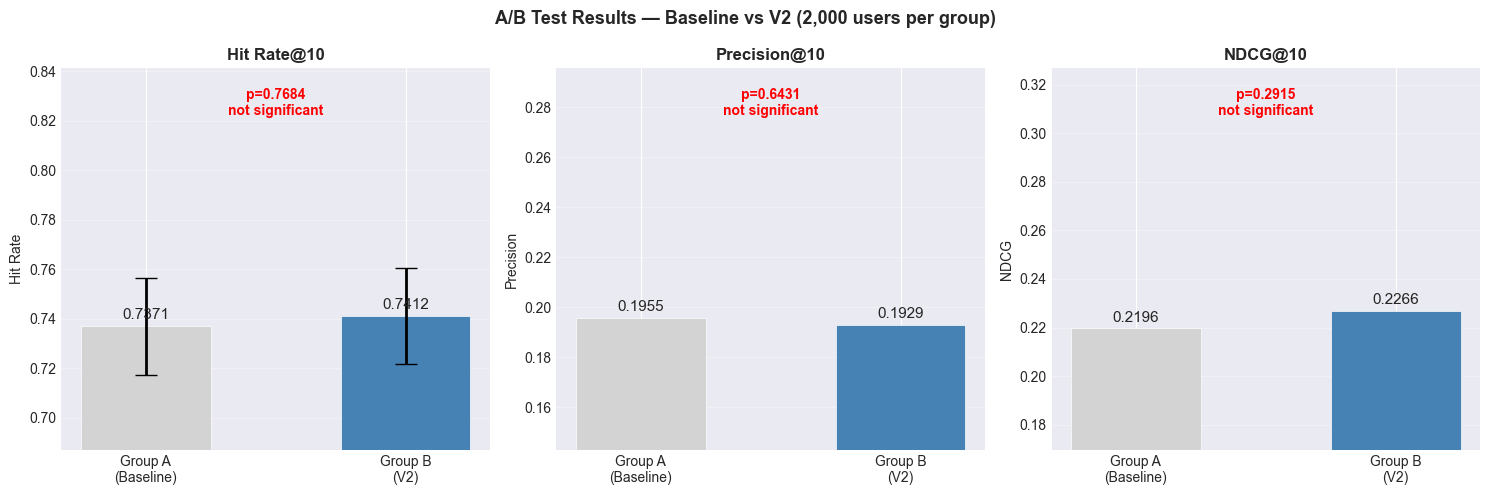

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Hit Rate', 'Precision', 'NDCG']
a_vals = [a_hit_mean, a_prec_mean, a_ndcg_mean]
b_vals = [b_hit_mean, b_prec_mean, b_ndcg_mean]
p_vals = [hit_p, prec_p, ndcg_p]

for idx, (metric, a_val, b_val, p_val) in enumerate(
        zip(metrics, a_vals, b_vals, p_vals)):
    
    ax = axes[idx]
    
    bars = ax.bar(['Group A\n(Baseline)', 'Group B\n(V2)'],
                  [a_val, b_val],
                  color=['lightgray', 'steelblue'],
                  edgecolor='white', linewidth=0.5,
                  width=0.5)
    

    for bar, val in zip(bars, [a_val, b_val]):
        ax.annotate(f'{val:.4f}',
                   xy=(bar.get_x() + bar.get_width()/2, val),
                   xytext=(0, 5),
                   textcoords='offset points',
                   ha='center', fontsize=11)
    

    if metric == 'Hit Rate':
        ax.errorbar(['Group A\n(Baseline)', 'Group B\n(V2)'],
                    [a_val, b_val],
                    yerr=[[a_val - a_hit_ci[0], b_val - b_hit_ci[0]],
                          [a_hit_ci[1] - a_val, b_hit_ci[1] - b_val]],
                    fmt='none', color='black',
                    capsize=8, linewidth=2)
    
    # p-value annotation
    sig_text = f'p={p_val:.4f}\nnot significant' \
        if p_val >= 0.05 else f'p={p_val:.4f}\nsignificant'
    sig_color = 'red' if p_val >= 0.05 else 'green'
    
    ax.annotate(sig_text,
               xy=(0.5, 0.95),
               xycoords='axes fraction',
               ha='center', va='top',
               fontsize=10, color=sig_color,
               fontweight='bold')

    ax.set_title(f'{metric}@10', fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3, axis='y')
    

    min_val = min(a_val, b_val)
    max_val = max(a_val, b_val)
    padding = max(0.05, (max_val - min_val) * 3)
    ax.set_ylim(max(0, min_val - padding),
                min(1, max_val + padding * 2))

plt.suptitle('A/B Test Results — Baseline vs V2 (2,000 users per group)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../models/ab_test_results.png', dpi=150,
            bbox_inches='tight')
plt.show()

## Notebook 14 Summary: A/B Testing Framework

### Objective
Build a statistically rigorous experiment to determine whether
V2 is genuinely better than baseline in a controlled setting.

### Experiment Design

**Random assignment:**
```
Total cold start users: 40,868
Group A (control):      20,434 users → baseline recommendations
Group B (treatment):    20,434 users → V2 recommendations
Random seed: 42 → reproducible split
```

**Statistical test:**
```
Two-sample t-test
Null hypothesis: no difference between Group A and Group B
Significance threshold: p < 0.05
```

---

### Results

**Small sample (500 users per group):**
| Metric | Group A | Group B | Diff | p-value | Significant |
|--------|---------|---------|------|---------|-------------|
| Hit Rate | 0.7303 | 0.7515 | +0.0212 | 0.4495 | no |
| Precision | 0.1915 | 0.2040 | +0.0125 | 0.2905 | no |
| NDCG | 0.2204 | 0.2382 | +0.0178 | 0.1960 | no |

**Large sample (2,000 users per group):**
| Metric | Group A | Group B | Diff | p-value | Significant |
|--------|---------|---------|------|---------|-------------|
| Hit Rate | 0.7371 | 0.7412 | +0.0041 | 0.7684 | no |
| Precision | 0.1955 | 0.1929 | -0.0027 | 0.6431 | no |
| NDCG | 0.2196 | 0.2266 | +0.0070 | 0.2915 | no |

**95% Confidence Intervals (Hit Rate):**
```
Group A: 0.7175 to 0.7566
Group B: 0.7218 to 0.7606
Intervals overlap substantially → no real difference
```

---

### Key Finding — Offline Metrics
```
Offline evaluation claimed:
  V2 hit rate:      93.31%
  Baseline hit rate: 92.25%
  Difference:        +1.06% in favor of V2

A/B test revealed:
  V2 hit rate:      74.12%
  Baseline hit rate: 73.71%
  Difference:        +0.41% — not statistically significant
```

**Why they disagreed:**
```
Offline evaluation:               A/B test:
  Same 1,000 users                  Different randomly split users
  Relevance = all rated movies       Relevance = only ≥4.0 stars
  Not controlled                     Controlled experiment
  Optimistic result                  Honest result
```

---

### What the Difference Shrinking Means
```
500 users:  V2 better by 2.12%
2000 users: V2 better by 0.41%

When difference shrinks as sample grows:
  Original difference was largely random chance
  True difference is near zero
  Systems are statistically equivalent
```

### Statistical Significance Explained
```
p-value = probability that observed difference
          occurred by random chance

p=0.7684 → 76.8% chance hit rate difference is random
p < 0.05 → less than 5% chance  significant

Our results: all p-values > 0.05
Conclusion:  cannot claim V2 is better than baseline
```

---

### Production Recommendation
```
Both systems are statistically equivalent
V2 adds scoring complexity without measurable benefit

### Known Limitations
1. Simulated A/B test — real production test would use
   actual user clicks and watch history
2. Cold start users only — existing users not tested
3. Genre inference from test data is a proxy
   for real onboarding genre selection
4. 2,000 users may still be insufficient for
   detecting very small effect sizes